In [6]:
import sys
!{sys.executable} -m pip install --user pandas seaborn folium

     |████████████████████████████████| 12.4MB 25.0MB/s eta 0:00:01
     |████████████████████████████████| 296kB 51.9MB/s eta 0:00:01
     |████████████████████████████████| 112kB 49.4MB/s eta 0:00:01
     |████████████████████████████████| 17.3MB 114kB/s  eta 0:00:01
     |████████████████████████████████| 358kB 50.7MB/s eta 0:00:01
     |████████████████████████████████| 9.2MB 33.7MB/s eta 0:00:0101
     |████████████████████████████████| 102kB 9.9MB/s eta 0:00:01
     |████████████████████████████████| 307kB 46.9MB/s eta 0:00:01
     |████████████████████████████████| 112kB 49.4MB/s eta 0:00:01
     |████████████████████████████████| 1.2MB 30.9MB/s eta 0:00:01
     |████████████████████████████████| 4.7MB 40.4MB/s eta 0:00:01
     |████████████████████████████████| 4.5MB 45.0MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this w

In [2]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName("F1_Preguntas")
    .enableHiveSupport()
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

spark.sql("USE f1_dw")

# Pregunta 1
q1 = spark.sql("""
SELECT nombre, apellido, victorias, pos
FROM (
    SELECT d.givenName  AS nombre,
           d.familyName AS apellido,
           COUNT(*)     AS victorias,
           RANK() OVER (ORDER BY COUNT(*) DESC) AS pos
    FROM fact_results f
    JOIN dim_driver d ON f.driverId = d.driverId
    WHERE f.position = 1
    GROUP BY d.givenName, d.familyName
) t
WHERE pos <= 10
ORDER BY pos, apellido, nombre
""")

# Pregunta 4
q4 = spark.sql("""
WITH podios_por_combo AS (
    SELECT d.givenName  AS nombre,
           d.familyName AS apellido,
           c.name       AS constructor,
           COUNT(*)     AS podios,
           RANK() OVER (ORDER BY COUNT(*) DESC) AS pos
    FROM fact_results f
    JOIN dim_driver      d ON f.driverId      = d.driverId
    JOIN dim_constructor c ON f.constructorId = c.constructorId
    WHERE f.position <= 3
    GROUP BY d.givenName, d.familyName, c.name
)
SELECT nombre, apellido, constructor, podios, pos
FROM podios_por_combo
WHERE pos <= 10
ORDER BY pos, apellido, nombre
""");

# Pase a pandas: solo para llevar resultados a visualización
p1 = q1.toPandas()
p4 = q4.toPandas()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-07-11T18:32:23,277 WARN [Thread-4] org.apache.hadoop.util.NativeCodeLoader - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-07-11T18:32:31,866 INFO [Thread-4] org.apache.hadoop.hive.conf.HiveConf - Found configuration file file:/home/ort/spark/conf/hive-site.xml
2026-07-11T18:32:32,126 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.metastore.wm.default.pool.size does not exist
2026-07-11T18:32:32,126 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.task.scheduler.preempt.independent does not exist
2026-07-11T18:32:32,126 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.output.format.arrow does not exist
2026-07-11T18:32:32,127 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.tez.llap.min.reducer.per.executor does not exist
2026-07-11T18:32:32,127 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf -

In [10]:
# P1 se presenta como tabla (su visualización asignada es esta salida tabular)
p1

,nombre,apellido,victorias,pos
0,Lewis,Hamilton,105,1
1,Max,Verstappen,71,2
2,Michael,Schumacher,56,3
3,Sebastian,Vettel,53,4
4,Fernando,Alonso,32,5
5,Nico,Rosberg,23,6
6,Kimi,Räikkönen,21,7
7,Jenson,Button,15,8
8,Rubens,Barrichello,11,9
9,Felipe,Massa,11,9


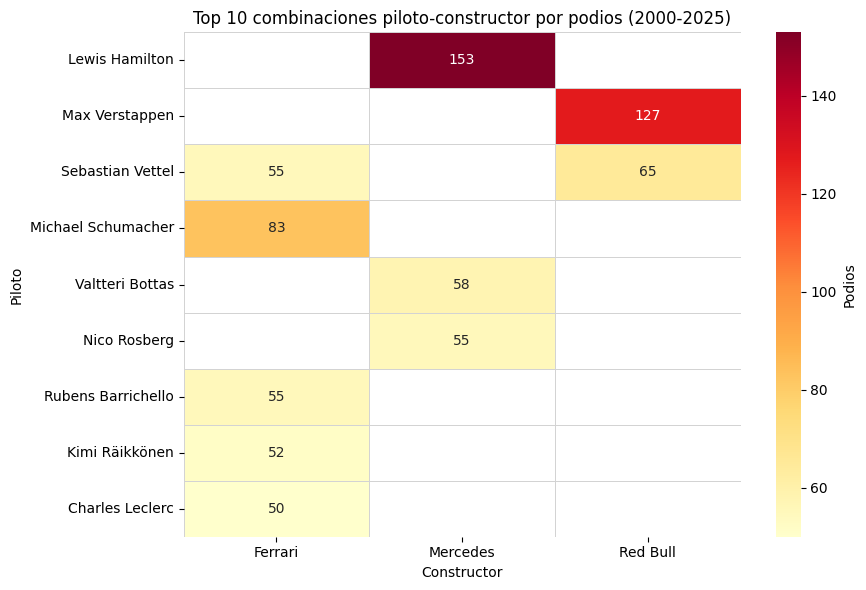

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz piloto x constructor con la cantidad de podios de cada combinación
p4["piloto"] = p4["nombre"] + " " + p4["apellido"]
matriz = p4.pivot_table(index="piloto", columns="constructor", values="podios")

# Filas ordenadas por podios (descendente) para que el ranking se lea de arriba hacia abajo
matriz = matriz.loc[matriz.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    matriz,
    annot=True, fmt=".0f",          # valor de podios en cada celda
    cmap="YlOrRd",
    linewidths=0.5, linecolor="lightgray",
    cbar_kws={"label": "Podios"},
    ax=ax,
)
ax.set_title("Top 10 combinaciones piloto-constructor por podios (2000-2025)")
ax.set_xlabel("Constructor")
ax.set_ylabel("Piloto")
plt.tight_layout()
# fig.savefig("viz2_heatmap_podios.png", dpi=150, bbox_inches="tight")
plt.show()